# 01 — Dataset Audit

This notebook performs a full audit of the raw `final_dataset/` before any processing begins. It checks class balance, file formats, image readability, resolution distribution, and provides visual samples of both classes.

**Input:** `final_dataset/class_0_genuine/` and `final_dataset/class_1_forged/`  
**Output:** `outputs/reports/dataset_metadata.csv`

---
## Contents
1. Configuration and imports
2. Build dataset inventory
3. Class distribution
4. File extension distribution
5. Image readability check and metadata extraction
6. Dimension statistics
7. Resolution distribution
8. Visual samples — genuine
9. Visual samples — forged
10. Export metadata CSV
11. Audit summary


## 1. Configuration and Imports

Defines the dataset root path, class-to-label mapping, and valid file extensions.

| Variable | Value |
|---|---|
| `CLASS_MAPPING` | `class_0_genuine → 0`, `class_1_forged → 1` |
| `VALID_EXTENSIONS` | `.png`, `.jpg`, `.jpeg`, `.bmp`, `.tif`, `.tiff` |

> ⚠️ Update `DATASET_ROOT` to your local path.


In [ ]:
from pathlib import Path
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import os

# Dataset path
DATASET_ROOT = Path(r"H:\UOR\7th sem\Computer Vision\final_dataset")

# Class mapping defined by our project
CLASS_MAPPING = {
    "class_0_genuine": 0,
    "class_1_forged": 1
}

LABEL_NAMES = {
    0: "genuine",
    1: "forged"
}

# Allowed image formats
VALID_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

print("Dataset root:", DATASET_ROOT)
print("Dataset exists:", DATASET_ROOT.exists())

Dataset root: D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\final_dataset\final_dataset
Dataset exists: True


## 2. Build Dataset Inventory

Recursively scans both class folders and builds a flat `DataFrame` (`df_dataset`) with one row per image file, recording: file path, filename, class folder, integer label, class name, and file extension.


In [85]:
# Empty list to store image records
dataset_records = []

# Iterate through each class folder and its label
for class_folder, label in CLASS_MAPPING.items():
    folder_path = DATASET_ROOT / class_folder
    
    if not folder_path.exists():
        print(f"WARNING: Missing folder: {folder_path}")
        continue
    
    # Recursive search through all subfolders
    for file_path in folder_path.rglob("*"):
        # Filter by valid image extensions only
        if file_path.is_file() and file_path.suffix.lower() in VALID_EXTENSIONS:
            dataset_records.append({
                "file_path": str(file_path),
                "file_name": file_path.name,
                "class_folder": class_folder,
                "label": label,
                "class_name": LABEL_NAMES[label],
                "extension": file_path.suffix.lower()
            })

# Convert records list to a DataFrame
df_dataset = pd.DataFrame(dataset_records)

print("Total valid image files found:", len(df_dataset))
df_dataset.head()

Total valid image files found: 543


,file_path,file_name,class_folder,label,class_name,extension
0,D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC...,Gen_A_300dpi_001.png,class_0_genuine,0,genuine,.png
1,D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC...,Gen_A_300dpi_002.png,class_0_genuine,0,genuine,.png
2,D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC...,Gen_A_300dpi_003.png,class_0_genuine,0,genuine,.png
3,D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC...,Gen_A_300dpi_004.png,class_0_genuine,0,genuine,.png
4,D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC...,Gen_A_300dpi_005.png,class_0_genuine,0,genuine,.png


## 3. Class Distribution

Plots a bar chart of image counts per class. The dataset should be approximately balanced (~150 genuine, ~150 forged) to avoid biasing the classifier.


Class distribution:
class_name
forged     217
genuine    326
Name: count, dtype: int64


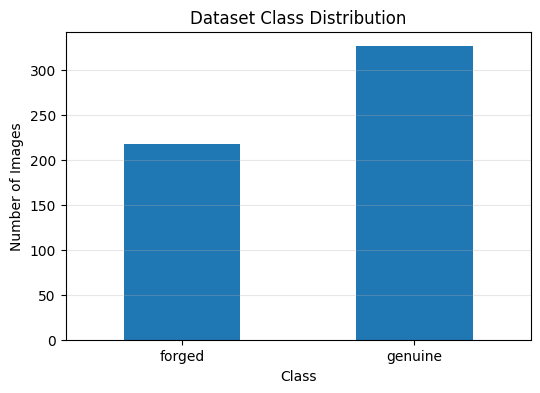

In [86]:
# Count images per class
class_counts = df_dataset["class_name"].value_counts().sort_index()

print("Class distribution:")
print(class_counts)

# Plot class distribution bar chart
plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Dataset Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
# Keep class names horizontal for readability
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.3)
plt.show()

## 4. File Extension Distribution

Counts how many images exist per file extension. All images in this project are expected to be `.png`.


In [87]:
extension_counts = df_dataset["extension"].value_counts()

print("Image file extension distribution:")
print(extension_counts)

Image file extension distribution:
extension
.png    543
Name: count, dtype: int64


## 5. Image Readability and Metadata Extraction

Attempts to open every image with OpenCV. Unreadable files are logged separately. For each readable image, records: pixel dimensions (width × height), channel count (3 = colour, 1 = grayscale).


In [88]:
unreadable_files = []
image_metadata = []

for _, row in df_dataset.iterrows():
    image_path = row["file_path"]
    image = cv2.imread(image_path)
    
    # None means the file is corrupt or unreadable by OpenCV
    if image is None:
        unreadable_files.append(image_path)
        continue
    
    # shape returns (height, width, channels)
    height, width = image.shape[:2]
    channels = image.shape[2] if len(image.shape) == 3 else 1
    
    image_metadata.append({
        "file_path": image_path,
        "file_name": row["file_name"],
        "class_name": row["class_name"],
        "label": row["label"],
        "width": width,
        "height": height,
        "channels": channels,
        "aspect_ratio": width / height if height != 0 else None
    })

df_metadata = pd.DataFrame(image_metadata)

print("Readable images:", len(df_metadata))
print("Unreadable images:", len(unreadable_files))

if unreadable_files:
    print("\nUnreadable file paths:")
    for path in unreadable_files:
        print(path)

Readable images: 543
Unreadable images: 0


## 6. Dimension Statistics

Prints descriptive statistics (min, max, mean, std) for image width and height across the dataset. High variance in resolution is expected because images were scanned at both 300 DPI and 600 DPI.


In [89]:
print("Image width statistics:")
print(df_metadata["width"].describe())

print("\nImage height statistics:")
print(df_metadata["height"].describe())

print("\nImage channel counts:")
print(df_metadata["channels"].value_counts())

Image width statistics:
count     543.000000
mean     3682.662983
std      1241.035190
min      2481.000000
25%      2481.000000
50%      2481.000000
75%      4962.000000
max      4962.000000
Name: width, dtype: float64

Image height statistics:
count     543.000000
mean     5204.602210
std      1754.256514
min      3506.000000
25%      3506.000000
50%      3506.000000
75%      7013.000000
max      7013.000000
Name: height, dtype: float64

Image channel counts:
channels
3    543
Name: count, dtype: int64


## 7. Resolution Distribution

Groups images by (width, height) pairs and ranks by frequency. Useful for confirming the two scanning resolutions (300 DPI and 600 DPI) are represented.


In [90]:
resolution_counts = (
    df_metadata
    .groupby(["width", "height"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print("Unique image resolutions:")
resolution_counts.head(10)

Unique image resolutions:


,width,height,count
0,2481,3506,280
1,4962,7013,263


## 8. Visual Samples — Genuine Class

In [91]:
def show_samples(df, class_name, n=4, display_width=500):
    class_df = df[df["class_name"] == class_name]

    if len(class_df) == 0:
        print(f"No images found for class: {class_name}")
        return

    sample_df = class_df.sample(
        n=min(n, len(class_df)),
        random_state=42
    )

    plt.figure(figsize=(16, 6))

    for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
        img = cv2.imread(row["file_path"])

        if img is None:
            print("Could not read:", row["file_path"])
            continue

        h, w = img.shape[:2]
        scale = display_width / w
        new_h = int(h * scale)

        img_small = cv2.resize(img, (display_width, new_h))
        img_rgb = cv2.cvtColor(img_small, cv2.COLOR_BGR2RGB)

        plt.subplot(1, len(sample_df), i)
        plt.imshow(img_rgb)
        plt.title(row["file_name"], fontsize=8)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

## 9. Visual Samples — Forged Class

Forged stamps were produced via the Scan-Print-Scan (SPS) method using inkjet and laser printers. Visually they appear similar to genuine stamps; the forensic difference is in the microscopic ink texture, not visible at this zoom level.


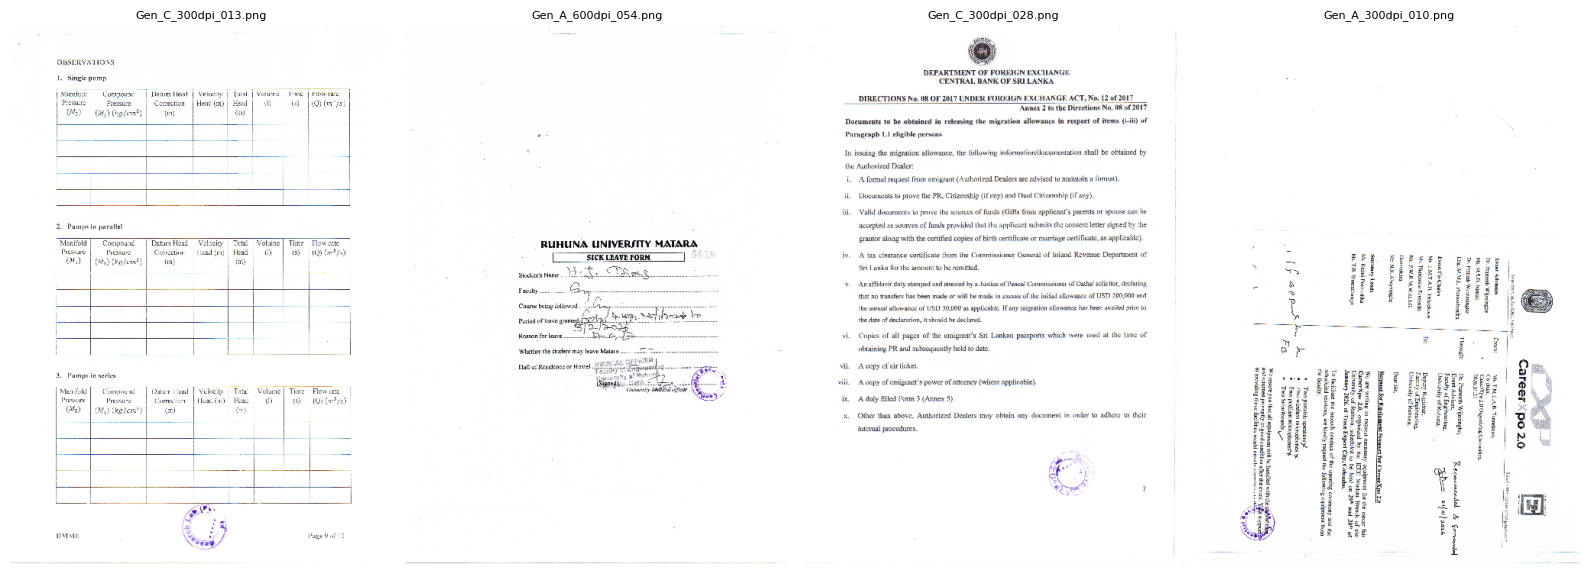

In [92]:
show_samples(df_metadata, "genuine", n=4)

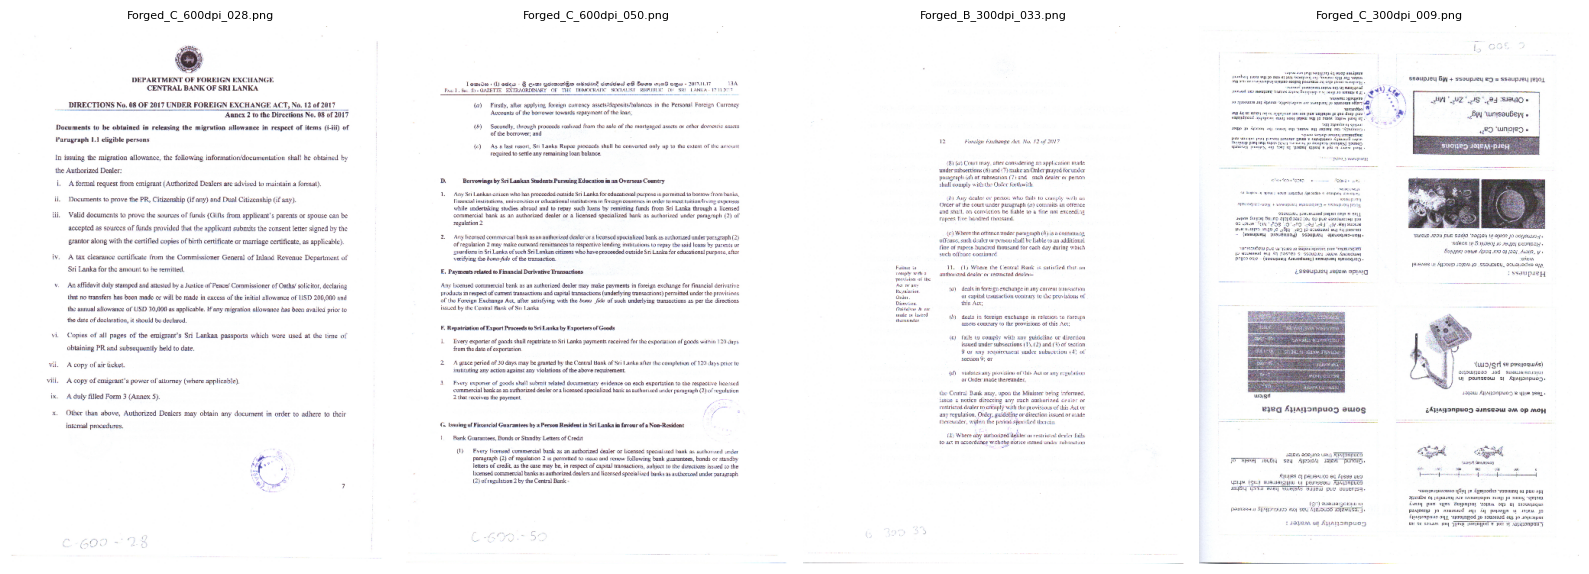

In [93]:
show_samples(df_metadata, "forged", n=4)

## 10. Export Metadata CSV

Saves `df_metadata` to `outputs/reports/dataset_metadata.csv` for reference in later notebooks.


In [94]:
OUTPUT_REPORT_DIR = Path("../outputs/reports")
OUTPUT_REPORT_DIR.mkdir(parents=True, exist_ok=True)

dataset_metadata_path = OUTPUT_REPORT_DIR / "dataset_metadata.csv"
df_metadata.to_csv(dataset_metadata_path, index=False)

print("Dataset metadata saved to:")
print(dataset_metadata_path.resolve())

Dataset metadata saved to:
D:\OneDrive - engug.ruh.ac.lk\2. Semester 7\EC7205 - IMAGE PROCESSING AND COMPUTER VISION\1. Project\forged-stamp-recognizer\outputs\reports\dataset_metadata.csv


## 11. Audit Summary

Prints a consolidated summary: total images, readable count, unreadable count, class distribution, extensions, and top resolutions. Review this before proceeding to preprocessing.


In [95]:
print("=" * 50)
print("DATASET AUDIT SUMMARY")
print("=" * 50)

print(f"Total valid images      : {len(df_dataset)}")
print(f"Readable images         : {len(df_metadata)}")
print(f"Unreadable images       : {len(unreadable_files)}")

print("\nClass distribution:")
print(df_metadata["class_name"].value_counts())

print("\nFile extensions:")
print(df_dataset["extension"].value_counts())

print("\nTop resolutions:")
print(resolution_counts.head())

print("=" * 50)

DATASET AUDIT SUMMARY
Total valid images      : 543
Readable images         : 543
Unreadable images       : 0

Class distribution:
class_name
genuine    326
forged     217
Name: count, dtype: int64

File extensions:
extension
.png    543
Name: count, dtype: int64

Top resolutions:
   width  height  count
0   2481    3506    280
1   4962    7013    263
